<a href="https://colab.research.google.com/github/aryanranga721-ops/Celebal_Internship/blob/main/Week4_Aryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models,optimizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

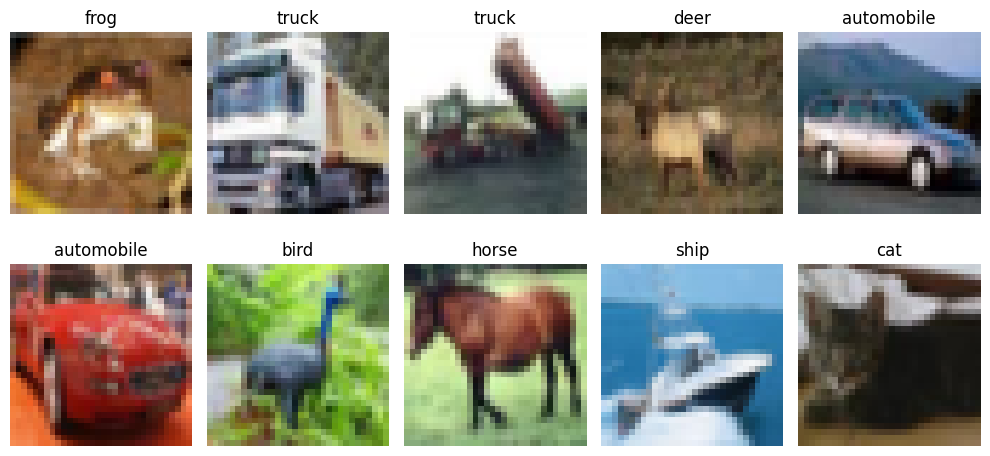

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2633 - loss: 2.0036 - val_accuracy: 0.3370 - val_loss: 1.8323
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3181 - loss: 1.8737 - val_accuracy: 0.3678 - val_loss: 1.7732
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3358 - loss: 1.8219 - val_accuracy: 0.3622 - val_loss: 1.7738
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3470 - loss: 1.7888 - val_accuracy: 0.3950 - val_loss: 1.7359
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3592 - loss: 1.7600 - val_accuracy: 0.3886 - val_loss: 1.7220
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3700 - loss: 1.7332 - val_accuracy: 0.4078 - val_loss: 1.6756
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3728 - loss: 1.7207 - val_accuracy: 0.4050 - val_loss: 1.6800
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3786 - loss: 1.7114 - val_accuracy: 0.

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4306 - loss: 1.6371
ANN Test Accuracy: 0.43059998750686646


#### **Increase ANN Layers**


In [8]:
ann_model2= models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

ann_history2 = ann_model2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping2]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2753 - loss: 1.9798 - val_accuracy: 0.3534 - val_loss: 1.8181
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3413 - loss: 1.8224 - val_accuracy: 0.3752 - val_loss: 1.7638
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3603 - loss: 1.7694 - val_accuracy: 0.3740 - val_loss: 1.7493
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3745 - loss: 1.7257 - val_accuracy: 0.4114 - val_loss: 1.6707
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3867 - loss: 1.6969 - val_accuracy: 0.4202 - val_loss: 1.6405
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3963 - loss: 1.6728 - val_accuracy: 0.4310 - val_loss: 1.6264
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4024 - loss: 1.6586 - val_accuracy: 0.4384 - val_loss: 1.5944
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4110 - loss: 1.6313 - val_accuracy: 0.

In [9]:
ann_test_loss2, ann_test_acc2 = ann_model2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4868 - loss: 1.4544
ANN Test Accuracy: 0.4867999851703644


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4524 - loss: 1.5236 - val_accuracy: 0.5662 - val_loss: 1.2245
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5977 - loss: 1.1449 - val_accuracy: 0.6084 - val_loss: 1.1103
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6617 - loss: 0.9759 - val_accuracy: 0.6480 - val_loss: 1.0235
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7051 - loss: 0.8500 - val_accuracy: 0.6320 - val_loss: 1.0938
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7354 - loss: 0.7564 - val_accuracy: 0.6392 - val_loss: 1.1316
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7642 - loss: 0.6757 - val_accuracy: 0.6214 - val_loss: 1.2904
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7886 - loss: 0.6056 - val_accuracy: 0.6186 - val_loss: 1.2148
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8080 - loss: 0.5466 - val_accuracy: 

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6918 - loss: 1.0850
CNN Test Accuracy: 0.6917999982833862


#### **Change CNN filters from 32→64→128 and Early Stoping**

In [12]:
cnn_model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
cnn_history2 = cnn_model2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=128
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.4525 - loss: 1.5225 - val_accuracy: 0.3014 - val_loss: 2.0865
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5948 - loss: 1.1489 - val_accuracy: 0.5754 - val_loss: 1.2037
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6627 - loss: 0.9606 - val_accuracy: 0.6668 - val_loss: 0.9726
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7065 - loss: 0.8386 - val_accuracy: 0.6808 - val_loss: 0.9328
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7422 - loss: 0.7358 - val_accuracy: 0.6788 - val_loss: 0.9548
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7706 - loss: 0.6579 - val_accuracy: 0.7204 - val_loss: 0.8474
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7958 - loss: 0.5796 - val_accuracy: 0.6868 - val_loss: 0.9393
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8162 - loss: 0.5181 - val_accuracy: 

In [13]:
cnn_test_loss2, cnn_test_acc2 = cnn_model2.evaluate(x_test_norm, y_test)
print("Improved CNN2 Test Accuracy:", cnn_test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7338 - loss: 1.2161
Improved CNN2 Test Accuracy: 0.7337999939918518


## 📈 Compare Learning Curves

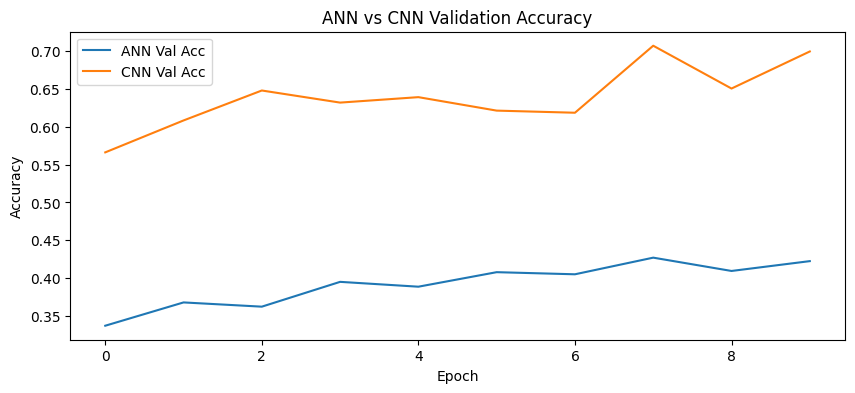

In [14]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

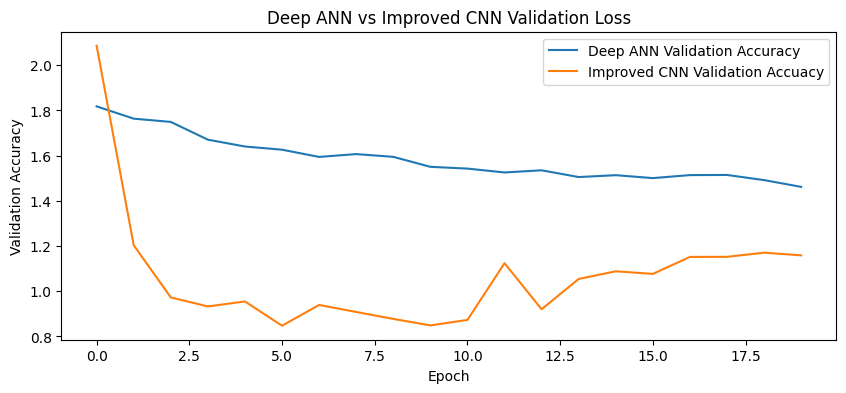

In [15]:
plt.figure(figsize=(10,4))
plt.plot(ann_history2.history['val_loss'], label='Deep ANN Validation Accuracy')
plt.plot(cnn_history2.history['val_loss'], label='Improved CNN Validation Accuacy')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Deep ANN vs Improved CNN Validation Loss")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.3797 - loss: 1.7027 - val_accuracy: 0.4604 - val_loss: 1.5405
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.4660 - loss: 1.4786 - val_accuracy: 0.5504 - val_loss: 1.2502
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5094 - loss: 1.3765 - val_accuracy: 0.5750 - val_loss: 1.1884
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5315 - loss: 1.3191 - val_accuracy: 0.6164 - val_loss: 1.0901
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5444 - loss: 1.2823 - val_accuracy: 0.6212 - val_loss: 1.0713
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5592 - loss: 1.2429 - val_accuracy: 0.6178 - val_loss: 1.0778
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5676 - loss: 1.2216 - val_accuracy: 0.6170 - val_loss: 1.1033
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5739 - loss: 1

# 📊 Final Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4306
1,CNN,0.6918


In [18]:
comparison2 = pd.DataFrame({
    "Model": ["Deep ANN", "Improved CNN"],
    "Test Accuracy": [ann_test_acc2, cnn_test_acc2]
})
comparison2

,Model,Test Accuracy
0,Deep ANN,0.4868
1,Improved CNN,0.7338


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
* **ANN works, but ignores image structure:** This project demonstrates the effectiveness of deep learning techniques for image classification using the CIFAR-10 dataset. Through a comparative analysis of Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs), it was observed that while ANNs can perform image classification, they are limited by their inability to preserve and learn spatial relationships within images.
* **CNN extracts spatial features, so it performs significantly better:** In contrast, CNNs are specifically designed to process image data and effectively extract hierarchical spatial features such as edges, textures, shapes, and object patterns. As a result, CNNs achieved significantly better classification performance and generalization compared to traditional ANN architectures.
* **Training strategies like dropout, batch norm, and augmentation improve results:** Furthermore, the incorporation of advanced training techniques, including Dropout, Batch Normalization, Data Augmentation, and Early Stopping, contributed to improved model stability, reduced overfitting, and enhanced predictive performance. These optimization strategies enabled the model to learn more robust feature representations and perform more effectively on unseen data.
* This project builds strong fundamentals for **computer vision interviews and deep learning projects:** Overall, this project provides practical experience in image preprocessing, neural network design, model evaluation, and performance optimization. It establishes a strong foundation in computer vision and deep learning concepts, making it valuable preparation for technical interviews, academic research, and real-world machine learning applications.